In [11]:
import pandas as pd
import matplotlib.pyplot as plt 

#### Procesamiento del dataset
___

In [3]:
# Lectura del dataset original
df = pd.read_csv("../data/raw/Características y composición del hogar.csv", sep=";") 
df

,DIRECTORIO,SECUENCIA_ENCUESTA,SECUENCIA_P,ORDEN,FEX_C,P6016,P1894,P6020,P6034,P6040,...,P1898,P1899,P3175,P1901,P1903,P1904,P1905,P1927,P3038,P3039
0,8369550,1,1,1,"472,1319014",1,3,2,1,45,...,10.0,5.0,7.0,10.0,6.0,0.0,7.0,6.0,1.0,2.0
1,8369550,2,1,2,"472,1319014",2,3,1,1,25,...,10.0,8.0,7.0,10.0,0.0,0.0,8.0,8.0,2.0,1.0
2,8369550,3,1,3,"472,1319014",3,2,2,1,16,...,10.0,10.0,10.0,10.0,0.0,0.0,10.0,10.0,NaN,NaN
3,8369550,4,1,4,"472,1319014",4,2,1,1,10,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8369551,1,1,1,"308,8543189",1,3,2,1,62,...,7.0,4.0,7.0,8.0,6.0,2.0,8.0,7.0,1.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235345,8489520,2,1,2,"19,04352805",2,3,2,1,31,...,10.0,10.0,10.0,10.0,1.0,0.0,9.0,9.0,1.0,2.0
235346,8489520,3,1,3,"19,04352805",3,1,2,1,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
235347,8489521,1,1,1,"19,04352805",1,3,1,1,31,...,10.0,9.0,9.0,10.0,1.0,0.0,10.0,9.0,2.0,1.0
235348,8489521,2,1,2,"19,04352805",2,3,2,1,32,...,10.0,10.0,9.0,9.0,1.0,1.0,10.0,9.0,1.0,2.0


In [4]:
# Filtro de variables
df_variables = df[["P6040", "P753S2", "P1897"]]
df_filtro = df_variables[
    (df_variables["P6040"] >= 18) &
    (df_variables["P753S2"] == 11001)
]

df_filtro.shape

(253, 3)

In [5]:
# Dataset sin filtro de municipio
df_variables = df[["P6040", "P1897"]]
df_filtro = df_variables[df_variables["P6040"] >= 18]

filtro = pd.DataFrame({
    "Población Total": [len(df)],
    "Población Mayor de Edad": [len(df_filtro)],
    "Porcentaje de la Muestra": [round(len(df_filtro) / len(df) * 100, 1)]
})

filtro

,Población Total,Población Mayor de Edad,Porcentaje de la Muestra
0,235350,172025,73.1


In [6]:
# Análisis de calidad
calidad_datos = pd.DataFrame({
    "No nulos": df_filtro.notna().sum(),
    "Nulos": df_filtro.isna().sum(),
    "% Nulos": (df_filtro.isna().sum() / len(df_filtro) * 100).round(1)
})
calidad_datos

,No nulos,Nulos,% Nulos
P6040,172025,0,0.0
P1897,172025,0,0.0


In [7]:
# Verificación de datos

pd.DataFrame({
    "min": df_filtro.min(),
    "max": df_filtro.max()
})

,min,max
P6040,18.0,108.0
P1897,0.0,10.0


In [8]:
df_desc = df_filtro.copy()
df_desc.head()

,P6040,P1897
0,45,10.0
1,25,10.0
4,62,7.0
5,38,8.0
6,49,8.0


3.1 ¿Cómo se ven los datos?



In [9]:
# Resumen de la edad
resumen_edad = pd.DataFrame({
    "promedio": [df_desc["P6040"].mean()],
    "mediana": [df_desc["P6040"].median()],
    "mínimo": [df_desc["P6040"].min()],
    "máximo": [df_desc["P6040"].max()],
}).round(1)

resumen_edad

,promedio,mediana,mínimo,máximo
0,45.8,44.0,18,108


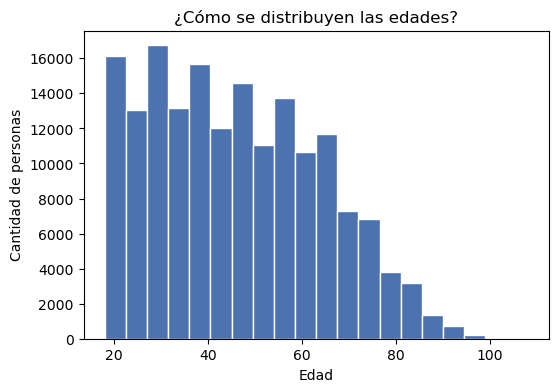

In [12]:
plt.figure(figsize=(6, 4))
plt.hist(df_desc["P6040"], bins=20, color="#4C72B0", edgecolor="white")
plt.title("¿Cómo se distribuyen las edades?")
plt.xlabel("Edad")
plt.ylabel("Cantidad de personas")
plt.show()

In [13]:
# Cuántas personas respondieron cada nivel de satisfacción (P1897)
tabla_satisfaccion = df_desc["P1897"].value_counts().sort_index()
porcentaje_satisfaccion = (tabla_satisfaccion / len(df_desc) * 100).round(1)

pd.DataFrame({"Cantidad de personas": tabla_satisfaccion, "% del total": porcentaje_satisfaccion})

,Cantidad de personas,% del total
P1897,,
0.0,852,0.5
1.0,436,0.3
2.0,1158,0.7
3.0,2487,1.4
4.0,4130,2.4
5.0,10845,6.3
6.0,14514,8.4
7.0,25652,14.9
8.0,44624,25.9


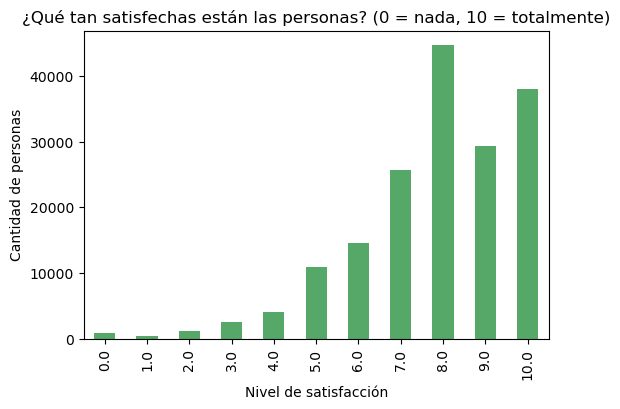

In [14]:
# Gráfico de barras de la satisfacción
plt.figure(figsize=(6, 4))
tabla_satisfaccion.plot(kind="bar", color="#55A868")
plt.title("¿Qué tan satisfechas están las personas? (0 = nada, 10 = totalmente)")
plt.xlabel("Nivel de satisfacción")
plt.ylabel("Cantidad de personas")
plt.show()

3.2 Relacion de precaucion

<Figure size 600x400 with 0 Axes>

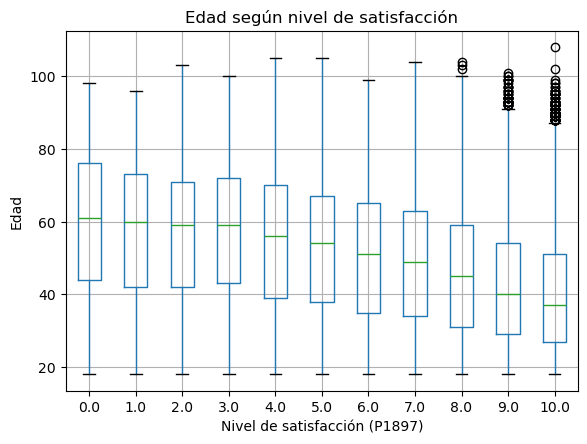

In [15]:
# Comparamos la edad según el nivel de satisfacción
plt.figure(figsize=(6, 4))
df_desc.boxplot(column="P6040", by="P1897")
plt.title("Edad según nivel de satisfacción")
plt.suptitle("")
plt.xlabel("Nivel de satisfacción (P1897)")
plt.ylabel("Edad")
plt.show()

3.3 ¿Hay valores raros en los datos?


In [17]:
# Las edades más altas y más bajas que aparecen en los datos
print("Las 10 edades más bajas:", sorted(df_desc["P6040"].unique())[:10])
print("Las 10 edades más altas:", sorted(df_desc["P6040"].unique())[-10:])

Las 10 edades más bajas: [np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27)]
Las 10 edades más altas: [np.int64(97), np.int64(98), np.int64(99), np.int64(100), np.int64(101), np.int64(102), np.int64(103), np.int64(104), np.int64(105), np.int64(108)]


4. Hallazgos

Los resultados muestran que la satisfacción con la salud se concentra principalmente en valores altos. El 80 % de las personas adultas analizadas reportó niveles de satisfacción entre 7 y 10, y específicamente el 65,1 % se ubicó entre 8 y 10. El nivel más frecuente fue 8, con el 25,9 % de las respuestas. En contraste, únicamente el 5,3 % reportó valores entre 0 y 4. Esto indica que dentro de la muestra analizada predomina una percepción más positiva del estado de salud.
Al comparar la edad con el nivel de satisfacción también se observa que las personas de mayor edad suelen ya concentrarse en niveles de satisfacción más bajos, y que las personas más jóvenes aparecen con mas frecuencia en niveles altos. Este resultado permite responder la pregunta analítica planteada porque sugiere que existe una relación entre la edad y la satisfacción con la salud. Sin embargo, esta asociación no permite concluir que una mayor edad sea la causa de una menor satisfacción. Pueden existir otras características relacionadas tanto con la edad como con la percepción de salud por ejemplo el estado de salud física, la situación laboral, los ingresos u otras condiciones de vida.


5. Reflexión

¿Qué fue lo más difícil al momento de transformar una necesidad de información en una pregunta analítica?
La principal dificultad creo que fue pasar de una necesidad amplia como comprender el bienestar de la población, a una pregunta específica que pudiera responderse con las variables disponibles. Fue necesario decidir qué dimensión del bienestar estudiar y qué característica de la población utilizar para compararla. Finalmente seleccionamos la edad y la satisfacción con la salud porque permiten formular una relación cuantitativa concreta y medible. También fue importante asegurarnos de que la pregunta no intentara responder demasiados aspectos al mismo tiempo. Eso fue lo que permitió pasar de un problema general sobre el bienestar a una pregunta bien enfocada sobre la relación entre edad y satisfacción con la salud.
¿Qué decisiones tuvieron que tomar durante la selección y preparación de los datos y cómo influyeron estas decisiones en el análisis?
Primero seleccionamos P6040, que correspondía a la edad, y P1897 que correspondía al nivel de satisfacción con la salud, por ser las variables necesarias para responder la pregunta analítica. Después se decidió conservar únicamente a las personas de 18 años o más, obteniendo una muestra de 172.025 registros. Inicialmente exploramos P753S2 para realizar el filtro geográfico, pero se reducía la muestra a aproximadamente 253 observaciones. Siguiendo la aclaración del profesor, se decidió no aplicar el filtro y trabajar solamente con el criterio de edad. También evalumos la calidad de las variables seleccionadas y se encontró que no presentaban valores faltantes y que sus valores estaban dentro de los rangos esperados. Por eso no fue necesario eliminar registros ni realizar imputaciones.
Estas decisiones permitieron conservar una muestra amplia para realizar el análisis descriptivo, pero también definieron el alcance de las conclusiones, los resultados permiten estudiar la relación entre edad y satisfacción con la salud dentro de la muestra adulta analizada, pero no establecer causalidad ni hacer afirmaciones exclusivamente sobre la población de Bogotá por los filtros dados.
